Bias and Proxy Discrimination in Automated Resume Screening Systems
USC DSCI — Course Project
Authors: Bhalgat, Solanki, Mohnalkar

Pipeline:
  1. Load & preprocess Kaggle resume dataset
  2. Inject synthetic demographic attributes + proxy correlations
  3. Generate biased hiring labels (gamma controls bias magnitude)
  4. Train baseline classifiers (LR, RF)
  5. Evaluate fairness metrics (DP, EO, EqOdds, PP)
  6. Proxy analysis (remove explicit demo features, re-evaluate)
  7. Bias mitigation (pre/in/post-processing)
  8. Trade-off analysis + plots

Requirements:
    pip install pandas numpy scikit-learn fairlearn aif360 matplotlib seaborn pdfplumber
    Dataset: folder-based, structured as data/<RoleName>/*.pdf

In [1]:
%pip install "scipy==1.15.3" "scikit-learn==1.6.1" "fairlearn==0.13.0" shap

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ─────────────────────────────────────────────
# CELL 1 — Imports
# ─────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.sparse
import scipy.sparse.linalg  # force load before sklearn

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)
from fairlearn.metrics import (
    demographic_parity_difference, equalized_odds_difference,
    MetricFrame, selection_rate, true_positive_rate, false_positive_rate,
)
from fairlearn.reductions import ExponentiatedGradient, DemographicParity
from fairlearn.postprocessing import ThresholdOptimizer
import warnings; warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
os.makedirs("figures", exist_ok=True)
print("Imports OK")

Imports OK


In [3]:
%pip install pdfplumber

Note: you may need to restart the kernel to use updated packages.


In [4]:
# ─────────────────────────────────────────────
# CELL 2 — Load & Preprocess PDFs
# ─────────────────────────────────────────────
import pdfplumber
from pathlib import Path

def load_and_preprocess(data_dir="data"):
    records = []
    data_path = Path(data_dir)
    for role_dir in sorted(data_path.iterdir()):
        if not role_dir.is_dir():
            continue
        category = role_dir.name
        pdf_files = list(role_dir.glob("*.pdf"))
        print(f"  {category}: {len(pdf_files)} PDFs")
        for pdf_path in pdf_files:
            try:
                with pdfplumber.open(pdf_path) as pdf:
                    text = " ".join(page.extract_text() or "" for page in pdf.pages)
                if text.strip():
                    records.append({"text": text, "category": category})
            except Exception as e:
                print(f"    Skipping {pdf_path.name}: {e}")
    df = pd.DataFrame(records)
    df["text"] = df["text"].str.lower().str.replace(r"[^a-z\s]", " ", regex=True)
    print(f"\nLoaded {len(df)} resumes across {df['category'].nunique()} categories.")
    return df

df = load_and_preprocess("data")

  ACCOUNTANT: 118 PDFs
  ADVOCATE: 118 PDFs
  AGRICULTURE: 63 PDFs
  APPAREL: 97 PDFs
  ARTS: 103 PDFs
  AUTOMOBILE: 36 PDFs
  AVIATION: 117 PDFs
  BANKING: 115 PDFs
  BPO: 22 PDFs
  BUSINESS-DEVELOPMENT: 120 PDFs
  CHEF: 118 PDFs
  CONSTRUCTION: 112 PDFs
  CONSULTANT: 115 PDFs
  DESIGNER: 107 PDFs
  DIGITAL-MEDIA: 96 PDFs
  ENGINEERING: 118 PDFs
  FINANCE: 118 PDFs
  FITNESS: 117 PDFs
  HEALTHCARE: 115 PDFs
  HR: 110 PDFs
  INFORMATION-TECHNOLOGY: 120 PDFs
  PUBLIC-RELATIONS: 111 PDFs
  SALES: 116 PDFs
  TEACHER: 102 PDFs

Loaded 2483 resumes across 24 categories.


In [5]:
# ─────────────────────────────────────────────
# CELL 3 — TF-IDF Feature Extraction
# ─────────────────────────────────────────────
def build_features(df, max_features=5000):
    vectorizer = TfidfVectorizer(max_features=max_features,
                                 stop_words="english", ngram_range=(1, 2))
    X_tfidf = vectorizer.fit_transform(df["text"]).toarray()
    proxy_raw = np.random.normal(0, 1, len(df))
    X = np.hstack([X_tfidf, proxy_raw.reshape(-1, 1)])
    print(f"Feature matrix shape: {X.shape}")
    return X, proxy_raw, vectorizer

X, proxy_raw, vectorizer = build_features(df)

Feature matrix shape: (2483, 5001)


In [6]:
# ─────────────────────────────────────────────
# CELL 4 — Demographic Injection + Label Generation
# ─────────────────────────────────────────────
def inject_demographics(X, proxy_raw, pi=0.5, gamma=1.5, proxy_correlation=0.7):
    n = len(X)
    A = np.random.binomial(1, pi, n)
    proxy_correlated = (proxy_correlation * (2 * A - 1)
                        + np.sqrt(1 - proxy_correlation**2) * proxy_raw)
    X[:, -1] = proxy_correlated

    svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
    Xq_reduced = svd.fit_transform(X[:, :-1])
    Xq_score = Xq_reduced[:, :5].mean(axis=1)
    Xq_score = (Xq_score - Xq_score.mean()) / (Xq_score.std() + 1e-8)

    logits = 2.0 * Xq_score + gamma * A
    probs = 1 / (1 + np.exp(-logits))
    Y = np.random.binomial(1, probs)

    print(f"Group A=0 selection rate: {Y[A==0].mean():.3f}")
    print(f"Group A=1 selection rate: {Y[A==1].mean():.3f}")
    print(f"Overall positive rate:    {Y.mean():.3f}")
    return X, A, Y

X, A, Y = inject_demographics(X, proxy_raw)

Group A=0 selection rate: 0.522
Group A=1 selection rate: 0.726
Overall positive rate:    0.622


In [7]:
# ─────────────────────────────────────────────
# CELL 5 — Scaling
# Train/test split is deferred to CELL 5b, after B is generated,
# so A and B are both available for the definitive split.
# ─────────────────────────────────────────────
scaler = StandardScaler(with_mean=False)
X_scaled = scaler.fit_transform(X)
print(f"Scaled feature matrix: {X_scaled.shape}")

Scaled feature matrix: (2483, 5001)


In [8]:
# ─────────────────────────────────────────────
# CELL 5b — Second Protected Attribute + Train/Test Split
# B (age proxy) is correlated with A but does NOT change Y.
# Comes after CELL 5 (needs scaler) and before CELL 6 (helpers).
# B influences selection only indirectly through Corr(A,B), which
# preserves all baseline results while enabling intersectional analysis.
# ─────────────────────────────────────────────
def inject_second_attribute(A, pi_B=0.5, rho_AB=0.3):
    """Generate B correlated with A. Y is unchanged."""
    n = len(A)
    noise = np.random.binomial(1, pi_B, n)
    B = np.where(np.random.rand(n) < rho_AB, A, noise)
    print(f"B distribution: {B.mean():.3f}  Corr(A, B) = {np.corrcoef(A, B)[0,1]:.3f}")
    print("Intersectional group sizes and selection rates (from original Y):")
    for a in [0, 1]:
        for b in [0, 1]:
            mask = (A == a) & (B == b)
            print(f"  A={a}, B={b}: n={mask.sum()}, sel_rate={Y[mask].mean():.3f}")
    return B

B = inject_second_attribute(A)

# Definitive train/test split — includes both A and B
# X_scaled is already computed in CELL 5; no need to refit the scaler.
X_tr, X_te, y_tr, y_te, A_tr, A_te, B_tr, B_te = train_test_split(
    X_scaled, Y, A, B, test_size=0.3, random_state=RANDOM_STATE, stratify=Y
)
print(f"\nTrain: {X_tr.shape}, Test: {X_te.shape}")

B distribution: 0.487  Corr(A, B) = 0.310
Intersectional group sizes and selection rates (from original Y):
  A=0, B=0: n=842, sel_rate=0.518
  A=0, B=1: n=424, sel_rate=0.531
  A=1, B=0: n=432, sel_rate=0.720
  A=1, B=1: n=785, sel_rate=0.729

Train: (1738, 5001), Test: (745, 5001)


In [9]:
# ─────────────────────────────────────────────
# CELL 6 — Helper Functions (eval)
# ─────────────────────────────────────────────
def eval_performance(y_true, y_pred, y_prob=None):
    m = {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall":    recall_score(y_true, y_pred, zero_division=0),
        "F1":        f1_score(y_true, y_pred, zero_division=0),
    }
    if y_prob is not None:
        m["AUC"] = roc_auc_score(y_true, y_prob)
    return m

def eval_fairness(y_true, y_pred, A):
    dp  = demographic_parity_difference(y_true, y_pred, sensitive_features=A)
    eod = equalized_odds_difference(y_true, y_pred, sensitive_features=A)
    mf  = MetricFrame(
        metrics={"TPR": true_positive_rate, "FPR": false_positive_rate,
                 "Sel": selection_rate},
        y_true=y_true, y_pred=y_pred, sensitive_features=A
    )
    return {
        "Dem. Parity Diff": round(dp, 4),
        "Eq. Odds Diff":    round(eod, 4),
        "EO (TPR) Diff":    round(abs(mf.by_group["TPR"].iloc[0]
                                      - mf.by_group["TPR"].iloc[1]), 4),
        "TPR (A=0)":        round(mf.by_group["TPR"].iloc[0], 4),
        "TPR (A=1)":        round(mf.by_group["TPR"].iloc[1], 4),
        "Sel Rate (A=0)":   round(mf.by_group["Sel"].iloc[0], 4),
        "Sel Rate (A=1)":   round(mf.by_group["Sel"].iloc[1], 4),
    }

print("Helpers defined")

Helpers defined


In [10]:
# ─────────────────────────────────────────────
# CELL 7 — Baseline Models
# ─────────────────────────────────────────────
baseline_results = {}

for name, model in [
    ("Logistic Regression", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("Random Forest",       RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
]:
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    perf = eval_performance(y_te, y_pred, y_prob)
    fair = eval_fairness(y_te, y_pred, A_te)
    baseline_results[name] = {"perf": perf, "fair": fair, "model": model, "pred": y_pred}
    print(f"\n{name}")
    print("  Perf:", {k: round(v,4) for k,v in perf.items()})
    print("  Fair:", fair)


Logistic Regression
  Perf: {'Accuracy': 0.7383, 'Precision': 0.7746, 'Recall': 0.8164, 'F1': 0.795, 'AUC': np.float64(0.7865)}
  Fair: {'Dem. Parity Diff': np.float64(0.0356), 'Eq. Odds Diff': 0.086, 'EO (TPR) Diff': np.float64(0.0599), 'TPR (A=0)': np.float64(0.8519), 'TPR (A=1)': np.float64(0.792), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.673)}

Random Forest
  Perf: {'Accuracy': 0.7906, 'Precision': 0.7786, 'Recall': 0.9266, 'F1': 0.8462, 'AUC': np.float64(0.8423)}
  Fair: {'Dem. Parity Diff': np.float64(0.0341), 'Eq. Odds Diff': 0.1663, 'EO (TPR) Diff': np.float64(0.0436), 'TPR (A=0)': np.float64(0.9524), 'TPR (A=1)': np.float64(0.9088), 'Sel Rate (A=0)': np.float64(0.7227), 'Sel Rate (A=1)': np.float64(0.7568)}


In [11]:
# ─────────────────────────────────────────────
# CELL 7b — Cross-Validation for Baseline Models
# ─────────────────────────────────────────────
from sklearn.model_selection import StratifiedKFold

cv_results = {}
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
perf_keys = ["Accuracy", "F1", "AUC"]
fair_keys = ["Dem. Parity Diff", "Eq. Odds Diff"]

for name, ModelClass, params in [
    ("Logistic Regression", LogisticRegression,   {"max_iter": 1000, "random_state": RANDOM_STATE}),
    ("Random Forest",       RandomForestClassifier, {"n_estimators": 100, "random_state": RANDOM_STATE}),
]:
    fold_perf, fold_fair = [], []

    for train_idx, test_idx in kf.split(X_scaled, Y):
        X_tr_cv, X_te_cv = X_scaled[train_idx], X_scaled[test_idx]
        y_tr_cv, y_te_cv = Y[train_idx], Y[test_idx]
        A_te_cv = A[test_idx]

        m = ModelClass(**params)
        m.fit(X_tr_cv, y_tr_cv)
        y_pred = m.predict(X_te_cv)
        y_prob = m.predict_proba(X_te_cv)[:, 1]

        fold_perf.append(eval_performance(y_te_cv, y_pred, y_prob))
        fold_fair.append(eval_fairness(y_te_cv, y_pred, A_te_cv))

    cv_results[name] = {
        "perf_mean": {k: round(np.mean([f[k] for f in fold_perf]), 4) for k in perf_keys},
        "perf_std":  {k: round(np.std( [f[k] for f in fold_perf]), 4) for k in perf_keys},
        "fair_mean": {k: round(np.mean([abs(f[k]) for f in fold_fair]), 4) for k in fair_keys},
        "fair_std":  {k: round(np.std( [abs(f[k]) for f in fold_fair]), 4) for k in fair_keys},
    }

    print(f"\n{name} — 5-Fold CV:")
    for k in perf_keys:
        print(f"  {k}: {cv_results[name]['perf_mean'][k]:.4f} ± {cv_results[name]['perf_std'][k]:.4f}")
    for k in fair_keys:
        print(f"  |{k}|: {cv_results[name]['fair_mean'][k]:.4f} ± {cv_results[name]['fair_std'][k]:.4f}")

# Save CV summary
cv_rows = []
for name, res in cv_results.items():
    row = {"Model": name}
    for k in perf_keys:
        row[f"{k}"] = f"{res['perf_mean'][k]} ± {res['perf_std'][k]}"
    for k in fair_keys:
        row[f"|{k}|"] = f"{res['fair_mean'][k]} ± {res['fair_std'][k]}"
    cv_rows.append(row)

cv_df = pd.DataFrame(cv_rows).set_index("Model")
cv_df.to_csv("figures/cv_summary.csv")
print("\n", cv_df.to_string())


Logistic Regression — 5-Fold CV:
  Accuracy: 0.7217 ± 0.0107
  F1: 0.7807 ± 0.0104
  AUC: 0.7685 ± 0.0115
  |Dem. Parity Diff|: 0.0273 ± 0.0161
  |Eq. Odds Diff|: 0.1590 ± 0.0577

Random Forest — 5-Fold CV:
  Accuracy: 0.7721 ± 0.0109
  F1: 0.8317 ± 0.0079
  AUC: 0.8174 ± 0.0086
  |Dem. Parity Diff|: 0.0280 ± 0.0208
  |Eq. Odds Diff|: 0.1723 ± 0.0488

                             Accuracy               F1              AUC |Dem. Parity Diff|  |Eq. Odds Diff|
Model                                                                                                     
Logistic Regression  0.7217 ± 0.0107  0.7807 ± 0.0104  0.7685 ± 0.0115    0.0273 ± 0.0161   0.159 ± 0.0577
Random Forest        0.7721 ± 0.0109  0.8317 ± 0.0079  0.8174 ± 0.0086     0.028 ± 0.0208  0.1723 ± 0.0488


In [12]:
# ─────────────────────────────────────────────
# CELL 8 — Proxy Analysis
# ─────────────────────────────────────────────
proxy_results = {}
X_tr_np = X_tr[:, :-1]   # remove proxy column
X_te_np = X_te[:, :-1]

for name, clf in [
    ("LR (no proxy)", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
    ("RF (no proxy)", RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)),
]:
    clf.fit(X_tr_np, y_tr)
    y_pred = clf.predict(X_te_np)
    y_prob = clf.predict_proba(X_te_np)[:, 1]
    perf = eval_performance(y_te, y_pred, y_prob)
    fair = eval_fairness(y_te, y_pred, A_te)
    proxy_results[name] = {"perf": perf, "fair": fair}
    print(f"\n{name}")
    print("  Perf:", {k: round(v,4) for k,v in perf.items()})
    print("  Fair:", fair)


LR (no proxy)
  Perf: {'Accuracy': 0.7369, 'Precision': 0.7753, 'Recall': 0.8121, 'F1': 0.7932, 'AUC': np.float64(0.7765)}
  Fair: {'Dem. Parity Diff': np.float64(0.0275), 'Eq. Odds Diff': 0.0964, 'EO (TPR) Diff': np.float64(0.0672), 'TPR (A=0)': np.float64(0.8519), 'TPR (A=1)': np.float64(0.7847), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.6649)}

RF (no proxy)
  Perf: {'Accuracy': 0.7852, 'Precision': 0.7701, 'Recall': 0.933, 'F1': 0.8438, 'AUC': np.float64(0.8332)}
  Fair: {'Dem. Parity Diff': np.float64(0.0235), 'Eq. Odds Diff': 0.1882, 'EO (TPR) Diff': np.float64(0.0416), 'TPR (A=0)': np.float64(0.9577), 'TPR (A=1)': np.float64(0.9161), 'Sel Rate (A=0)': np.float64(0.7413), 'Sel Rate (A=1)': np.float64(0.7649)}


In [13]:
# CELL 8b — Top proxy features by RF importance
rf_model = baseline_results["Random Forest"]["model"]
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[-20:][::-1]  # top 20 features

# You need the vectorizer — re-run Cell 3 saving it:
# vectorizer = TfidfVectorizer(...)  → save as global variable
# Then:
feature_names = vectorizer.get_feature_names_out().tolist() + ["proxy_score"]
top_features = [(feature_names[i], round(importances[i], 5)) for i in top_idx]
print("Top 20 features by RF importance:")
for name, imp in top_features:
    print(f"  {name}: {imp}")

Top 20 features by RF importance:
  design: 0.01048
  engineering: 0.00772
  systems: 0.00755
  construction: 0.00723
  accounts: 0.00637
  installation: 0.00593
  proxy_score: 0.00534
  technical: 0.00532
  mechanical: 0.00484
  project: 0.00472
  monthly: 0.00458
  account: 0.00413
  engineer: 0.00362
  employee: 0.00342
  sales: 0.00327
  electrical: 0.0031
  state: 0.00299
  reports: 0.00297
  weekly: 0.00287
  accounting: 0.00286


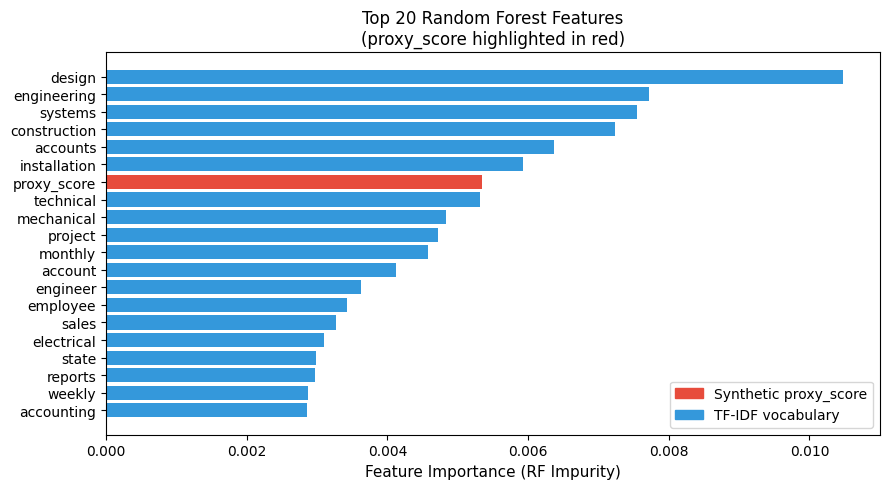

In [14]:
# CELL 8c — Feature Importance Bar Chart (Figure 3 for paper)
fig, ax = plt.subplots(figsize=(9, 5))
names = [f[0] for f in top_features]
vals  = [f[1] for f in top_features]
colors_fi = ["#e74c3c" if n == "proxy_score" else "#3498db" for n in names]

ax.barh(names[::-1], vals[::-1], color=colors_fi[::-1])
ax.set_xlabel("Feature Importance (RF Impurity)", fontsize=11)
ax.set_title("Top 20 Random Forest Features\n(proxy_score highlighted in red)", fontsize=12)

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Synthetic proxy_score"),
                   Patch(color="#3498db", label="TF-IDF vocabulary")])
plt.tight_layout()
plt.savefig("figures/feature_importance.png", dpi=150)
plt.show()

In [15]:
# ─────────────────────────────────────────────
# CELL 9 — Bias Mitigation
# ─────────────────────────────────────────────
from fairlearn.reductions import EqualizedOdds as EqOddsConstraint
mitigation_results = {}

# Pre-processing: reweighting — upweight A=1 (under-selected group in predictions)
weights = np.where(A_tr == 1, 2.0, 1.0)
lr_pre = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
lr_pre.fit(X_tr, y_tr, sample_weight=weights)
y_pred_pre = lr_pre.predict(X_te)
mitigation_results["LR Reweighting (Pre)"] = {
    "perf": eval_performance(y_te, y_pred_pre, lr_pre.predict_proba(X_te)[:,1]),
    "fair": eval_fairness(y_te, y_pred_pre, A_te),
    "pred": y_pred_pre,
}
print("Pre-processing done:", mitigation_results["LR Reweighting (Pre)"]["fair"])

# In-processing: ExponentiatedGradient — Demographic Parity constraint
# eps=0.05 avoids over-tight constraint that causes train/test fairness generalization gap
eg = ExponentiatedGradient(
    LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    constraints=DemographicParity(), eps=0.05
)
eg.fit(X_tr, y_tr, sensitive_features=A_tr)
y_pred_eg = eg.predict(X_te)
mitigation_results["ExpGrad DP (In)"] = {
    "perf": eval_performance(y_te, y_pred_eg),
    "fair": eval_fairness(y_te, y_pred_eg, A_te),
    "pred": y_pred_eg,
}
print("In-processing DP done:", mitigation_results["ExpGrad DP (In)"]["fair"])

# In-processing: ExponentiatedGradient — Equalized Odds constraint
# eps=0.10 forces a meaningfully different constrained solution from the baseline
eg_eo = ExponentiatedGradient(
    LogisticRegression(max_iter=500, random_state=RANDOM_STATE),
    constraints=EqOddsConstraint(), eps=0.10
)
eg_eo.fit(X_tr, y_tr, sensitive_features=A_tr)
y_pred_eg_eo = eg_eo.predict(X_te)
mitigation_results["ExpGrad EO (In)"] = {
    "perf": eval_performance(y_te, y_pred_eg_eo),
    "fair": eval_fairness(y_te, y_pred_eg_eo, A_te),
    "pred": y_pred_eg_eo,
}
print("In-processing EO done:", mitigation_results["ExpGrad EO (In)"]["fair"])

# Post-processing: ThresholdOptimizer with demographic_parity constraint.
# When baseline DP gap is small, the optimizer over-corrects and inverts disparity
# direction — a known failure mode of threshold-based post-processing.
base_lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
base_lr.fit(X_tr, y_tr)
topt = ThresholdOptimizer(
    estimator=base_lr,
    constraints="demographic_parity",
    objective="accuracy_score",
    predict_method="predict_proba",
)
topt.fit(X_tr, y_tr, sensitive_features=A_tr)
y_pred_to = topt.predict(X_te, sensitive_features=A_te)
mitigation_results["ThresholdOpt (Post)"] = {
    "perf": eval_performance(y_te, y_pred_to),
    "fair": eval_fairness(y_te, y_pred_to, A_te),
    "pred": y_pred_to,
}
print("Post-processing done:", mitigation_results["ThresholdOpt (Post)"]["fair"])

Pre-processing done: {'Dem. Parity Diff': np.float64(0.0383), 'Eq. Odds Diff': 0.0914, 'EO (TPR) Diff': np.float64(0.0509), 'TPR (A=0)': np.float64(0.8466), 'TPR (A=1)': np.float64(0.7956), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.6757)}
In-processing DP done: {'Dem. Parity Diff': np.float64(0.0026), 'Eq. Odds Diff': 0.1001, 'EO (TPR) Diff': np.float64(0.0999), 'TPR (A=0)': np.float64(0.8042), 'TPR (A=1)': np.float64(0.7044), 'Sel Rate (A=0)': np.float64(0.5893), 'Sel Rate (A=1)': np.float64(0.5919)}
In-processing EO done: {'Dem. Parity Diff': np.float64(0.0356), 'Eq. Odds Diff': 0.086, 'EO (TPR) Diff': np.float64(0.0599), 'TPR (A=0)': np.float64(0.8519), 'TPR (A=1)': np.float64(0.792), 'Sel Rate (A=0)': np.float64(0.6373), 'Sel Rate (A=1)': np.float64(0.673)}
Post-processing done: {'Dem. Parity Diff': np.float64(0.1454), 'Eq. Odds Diff': 0.2716, 'EO (TPR) Diff': np.float64(0.2716), 'TPR (A=0)': np.float64(0.8519), 'TPR (A=1)': np.float64(0.5803), 'Sel Rate 

In [16]:
# CELL 9b — Understand ThresholdOpt direction
print("Baseline LR:")
print(f"  Sel Rate A=0: {baseline_results['Logistic Regression']['fair']['Sel Rate (A=0)']}")
print(f"  Sel Rate A=1: {baseline_results['Logistic Regression']['fair']['Sel Rate (A=1)']}")
print("\nThresholdOpt:")
print(f"  Sel Rate A=0: {mitigation_results['ThresholdOpt (Post)']['fair']['Sel Rate (A=0)']}")
print(f"  Sel Rate A=1: {mitigation_results['ThresholdOpt (Post)']['fair']['Sel Rate (A=1)']}")

Baseline LR:
  Sel Rate A=0: 0.6373
  Sel Rate A=1: 0.673

ThresholdOpt:
  Sel Rate A=0: 0.6373
  Sel Rate A=1: 0.4919


In [17]:
# ─────────────────────────────────────────────
# CELL 9c — Mitigation Applied to Random Forest
# Addresses: "mitigations only applied to LR" weakness
# ─────────────────────────────────────────────

# Pre-processing: reweighting — upweight A=1 (under-selected group in predictions)
weights_rf = np.where(A_tr == 1, 2.0, 1.0)
rf_pre = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
rf_pre.fit(X_tr, y_tr, sample_weight=weights_rf)
y_pred_rf_pre = rf_pre.predict(X_te)
mitigation_results["RF Reweighting (Pre)"] = {
    "perf": eval_performance(y_te, y_pred_rf_pre, rf_pre.predict_proba(X_te)[:,1]),
    "fair": eval_fairness(y_te, y_pred_rf_pre, A_te),
    "pred": y_pred_rf_pre,
}
print("RF pre-processing:", mitigation_results["RF Reweighting (Pre)"]["fair"])

# In-processing: ExponentiatedGradient with RF base learner
rf_eg = ExponentiatedGradient(
    RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE),
    constraints=DemographicParity(), eps=0.01
)
rf_eg.fit(X_tr, y_tr, sensitive_features=A_tr)
y_pred_rf_eg = rf_eg.predict(X_te)
mitigation_results["RF ExpGrad DP (In)"] = {
    "perf": eval_performance(y_te, y_pred_rf_eg),
    "fair": eval_fairness(y_te, y_pred_rf_eg, A_te),
    "pred": y_pred_rf_eg,
}
print("RF in-processing:", mitigation_results["RF ExpGrad DP (In)"]["fair"])

# ThresholdOptimizer is intentionally NOT applied to RF: RF predict_proba outputs
# are not calibrated (leaf-vote proportions), so applying it would confound results.
print("\nNote: ThresholdOptimizer skipped for RF — uncalibrated probabilities.")

RF pre-processing: {'Dem. Parity Diff': np.float64(0.0074), 'Eq. Odds Diff': 0.1932, 'EO (TPR) Diff': np.float64(0.0668), 'TPR (A=0)': np.float64(0.9683), 'TPR (A=1)': np.float64(0.9015), 'Sel Rate (A=0)': np.float64(0.744), 'Sel Rate (A=1)': np.float64(0.7514)}
RF in-processing: {'Dem. Parity Diff': np.float64(0.0055), 'Eq. Odds Diff': 0.1583, 'EO (TPR) Diff': np.float64(0.0767), 'TPR (A=0)': np.float64(0.7884), 'TPR (A=1)': np.float64(0.7117), 'Sel Rate (A=0)': np.float64(0.5947), 'Sel Rate (A=1)': np.float64(0.5892)}

Note: ThresholdOptimizer skipped for RF — uncalibrated probabilities.


In [18]:
# ─────────────────────────────────────────────
# CELL 10 — Summary Table
# ─────────────────────────────────────────────
all_results = {**baseline_results, **mitigation_results}
rows = []
for name, res in all_results.items():
    row = {"Model": name}
    row.update({k: round(v,4) for k,v in res["perf"].items()
                if k in ["Accuracy","F1","AUC"]})
    row.update({k: round(abs(v),4) for k,v in res["fair"].items()
                if k in ["Dem. Parity Diff","Eq. Odds Diff"]})
    rows.append(row)

summary_df = pd.DataFrame(rows).set_index("Model")
summary_df.to_csv("figures/summary_table.csv")
print(summary_df.to_string())

                      Accuracy      F1     AUC  Dem. Parity Diff  Eq. Odds Diff
Model                                                                          
Logistic Regression     0.7383  0.7950  0.7865            0.0356         0.0860
Random Forest           0.7906  0.8462  0.8423            0.0341         0.1663
LR Reweighting (Pre)    0.7369  0.7941  0.7835            0.0383         0.0914
ExpGrad DP (In)         0.7141  0.7641     NaN            0.0026         0.1001
ExpGrad EO (In)         0.7383  0.7950     NaN            0.0356         0.0860
ThresholdOpt (Post)     0.6725  0.7240     NaN            0.1454         0.2716
RF Reweighting (Pre)    0.7852  0.8431  0.8424            0.0074         0.1932
RF ExpGrad DP (In)      0.7101  0.7611     NaN            0.0055         0.1583


In [19]:
# CELL 10b — Proxy Comparison Table with Explicit % Change
proxy_rows = []
for base_name, proxy_name in [("Logistic Regression", "LR (no proxy)"),
                               ("Random Forest",       "RF (no proxy)")]:
    b = baseline_results[base_name]
    p = proxy_results[proxy_name]
    dp_with    = round(abs(b["fair"]["Dem. Parity Diff"]), 4)
    dp_without = round(abs(p["fair"]["Dem. Parity Diff"]), 4)
    eo_with    = round(abs(b["fair"]["Eq. Odds Diff"]), 4)
    eo_without = round(abs(p["fair"]["Eq. Odds Diff"]), 4)
    dp_pct = (dp_without - dp_with) / dp_with * 100
    eo_pct = (eo_without - eo_with) / eo_with * 100
    proxy_rows.append({
        "Model":         base_name,
        "DP (proxy)":    dp_with,
        "DP (no proxy)": dp_without,
        "DP % change":   f"{dp_pct:+.1f}%",
        "EO (proxy)":    eo_with,
        "EO (no proxy)": eo_without,
        "EO % change":   f"{eo_pct:+.1f}%",
    })

proxy_df = pd.DataFrame(proxy_rows).set_index("Model")
proxy_df.to_csv("figures/proxy_comparison.csv")
print(proxy_df.to_string())
print("\nNote: negative DP % = proxy removal reduces parity gap (desired)")
print("      positive EO % = proxy removal worsens equalized-odds gap")
print("      (EO increase means proxy was partially masking TPR/FPR disparities)")

                     DP (proxy)  DP (no proxy) DP % change  EO (proxy)  EO (no proxy) EO % change
Model                                                                                            
Logistic Regression      0.0356         0.0275      -22.8%      0.0860         0.0964      +12.1%
Random Forest            0.0341         0.0235      -31.1%      0.1663         0.1882      +13.2%

Note: negative DP % = proxy removal reduces parity gap (desired)
      positive EO % = proxy removal worsens equalized-odds gap
      (EO increase means proxy was partially masking TPR/FPR disparities)


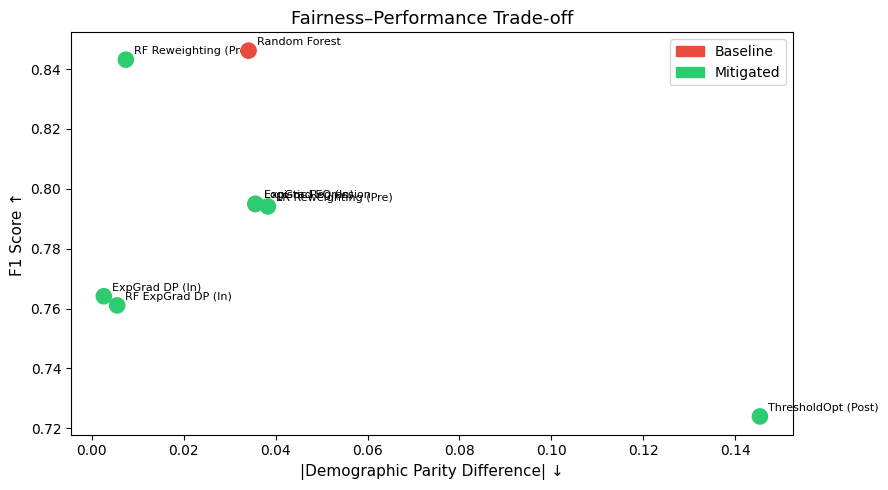

In [20]:
# ─────────────────────────────────────────────
# CELL 11 — Fairness–Performance Trade-off Plot
# ─────────────────────────────────────────────
labels  = list(all_results.keys())
dp_vals = [abs(r["fair"]["Dem. Parity Diff"]) for r in all_results.values()]
f1_vals = [r["perf"]["F1"] for r in all_results.values()]
colors  = (["#e74c3c"] * len(baseline_results)
         + ["#2ecc71"] * len(mitigation_results))

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(dp_vals, f1_vals, c=colors, s=120, zorder=5)
for i, lbl in enumerate(labels):
    ax.annotate(lbl, (dp_vals[i], f1_vals[i]),
                textcoords="offset points", xytext=(6,4), fontsize=8)
ax.set_xlabel("|Demographic Parity Difference| ↓", fontsize=11)
ax.set_ylabel("F1 Score ↑", fontsize=11)
ax.set_title("Fairness–Performance Trade-off", fontsize=13)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color="#e74c3c", label="Baseline"),
                   Patch(color="#2ecc71", label="Mitigated")])
plt.tight_layout()
plt.savefig("figures/fairness_tradeoff.png", dpi=150)
plt.show()

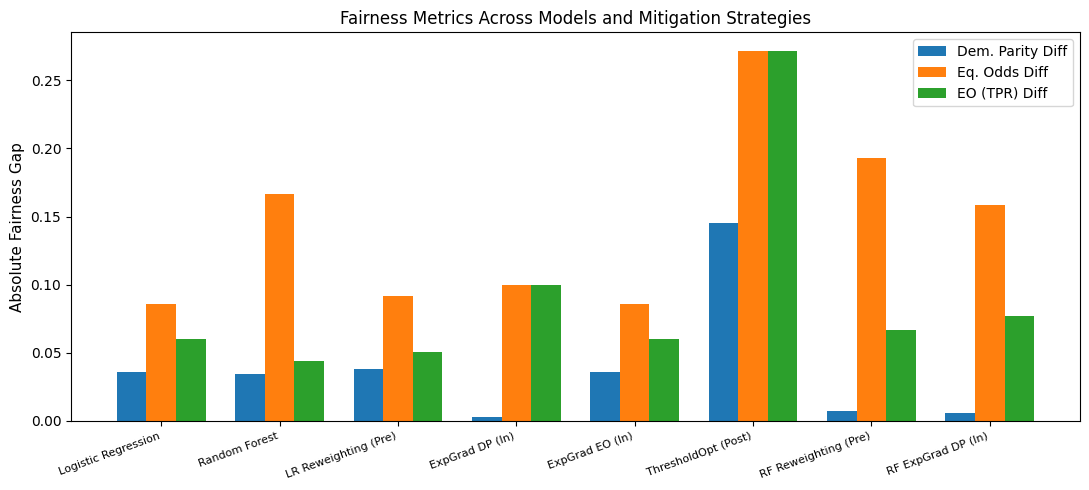

In [21]:
# ─────────────────────────────────────────────
# CELL 12 — Fairness Metrics Bar Chart
# ─────────────────────────────────────────────
metrics  = ["Dem. Parity Diff", "Eq. Odds Diff", "EO (TPR) Diff"]
data     = {m: [abs(r["fair"][m]) for r in all_results.values()] for m in metrics}
x, w     = np.arange(len(all_results)), 0.25

fig, ax = plt.subplots(figsize=(11, 5))
for i, (m, vals) in enumerate(data.items()):
    ax.bar(x + i*w, vals, w, label=m)
ax.set_xticks(x + w)
ax.set_xticklabels(list(all_results.keys()), rotation=20, ha="right", fontsize=8)
ax.set_ylabel("Absolute Fairness Gap", fontsize=11)
ax.set_title("Fairness Metrics Across Models and Mitigation Strategies", fontsize=12)
ax.legend()
plt.tight_layout()
plt.savefig("figures/fairness_metrics_bar.png", dpi=150)
plt.show()

In [22]:
# ─────────────────────────────────────────────
# CELL 13a — Sensitivity Analysis Over (rho, gamma)
# Addresses: "no sensitivity analysis" weakness
# ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler as _SS

def sensitivity_run(rho, gamma):
    np.random.seed(RANDOM_STATE)
    n = len(X)
    A_s = np.random.binomial(1, 0.5, n)
    proxy_corr = (rho * (2 * A_s - 1)
                  + np.sqrt(1 - rho**2) * np.random.normal(0, 1, n))
    X_s = X.copy()
    X_s[:, -1] = proxy_corr

    svd = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
    Xq = svd.fit_transform(X_s[:, :-1])[:, :5].mean(axis=1)
    Xq = (Xq - Xq.mean()) / (Xq.std() + 1e-8)

    Y_s = np.random.binomial(1, 1 / (1 + np.exp(-(2.0 * Xq + gamma * A_s))))
    X_sc = _SS(with_mean=False).fit_transform(X_s)
    X_tr_s, X_te_s, y_tr_s, y_te_s, A_tr_s, A_te_s = train_test_split(
        X_sc, Y_s, A_s, test_size=0.3, random_state=RANDOM_STATE, stratify=Y_s
    )
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    lr.fit(X_tr_s, y_tr_s)
    y_pred = lr.predict(X_te_s)
    return (abs(demographic_parity_difference(y_te_s, y_pred, sensitive_features=A_te_s)),
            abs(equalized_odds_difference(y_te_s, y_pred, sensitive_features=A_te_s)))

rhos, gammas = [0.3, 0.5, 0.7, 0.9], [0.5, 1.0, 1.5, 2.0]
dp_grid  = np.zeros((len(rhos), len(gammas)))
eod_grid = np.zeros((len(rhos), len(gammas)))

for i, rho in enumerate(rhos):
    for j, gamma in enumerate(gammas):
        dp_grid[i,j], eod_grid[i,j] = sensitivity_run(rho, gamma)
        print(f"  rho={rho}, gamma={gamma}: DP={dp_grid[i,j]:.3f}, EqOdds={eod_grid[i,j]:.3f}")

sens_df = pd.DataFrame(dp_grid, index=[f"rho={r}" for r in rhos],
                       columns=[f"gamma={g}" for g in gammas])
sens_df.to_csv("figures/sensitivity_dp.csv")
print("\nDP Difference grid:\n", sens_df.round(3))

  rho=0.3, gamma=0.5: DP=0.016, EqOdds=0.080
  rho=0.3, gamma=1.0: DP=0.014, EqOdds=0.131
  rho=0.3, gamma=1.5: DP=0.011, EqOdds=0.076
  rho=0.3, gamma=2.0: DP=0.024, EqOdds=0.131
  rho=0.5, gamma=0.5: DP=0.008, EqOdds=0.072
  rho=0.5, gamma=1.0: DP=0.006, EqOdds=0.103
  rho=0.5, gamma=1.5: DP=0.007, EqOdds=0.067
  rho=0.5, gamma=2.0: DP=0.035, EqOdds=0.109
  rho=0.7, gamma=0.5: DP=0.003, EqOdds=0.066
  rho=0.7, gamma=1.0: DP=0.015, EqOdds=0.070
  rho=0.7, gamma=1.5: DP=0.040, EqOdds=0.039
  rho=0.7, gamma=2.0: DP=0.054, EqOdds=0.086
  rho=0.9, gamma=0.5: DP=0.000, EqOdds=0.061
  rho=0.9, gamma=1.0: DP=0.029, EqOdds=0.065
  rho=0.9, gamma=1.5: DP=0.069, EqOdds=0.023
  rho=0.9, gamma=2.0: DP=0.086, EqOdds=0.062

DP Difference grid:
          gamma=0.5  gamma=1.0  gamma=1.5  gamma=2.0
rho=0.3      0.016      0.014      0.011      0.024
rho=0.5      0.008      0.006      0.007      0.035
rho=0.7      0.003      0.015      0.040      0.054
rho=0.9      0.000      0.029      0.069      0.08

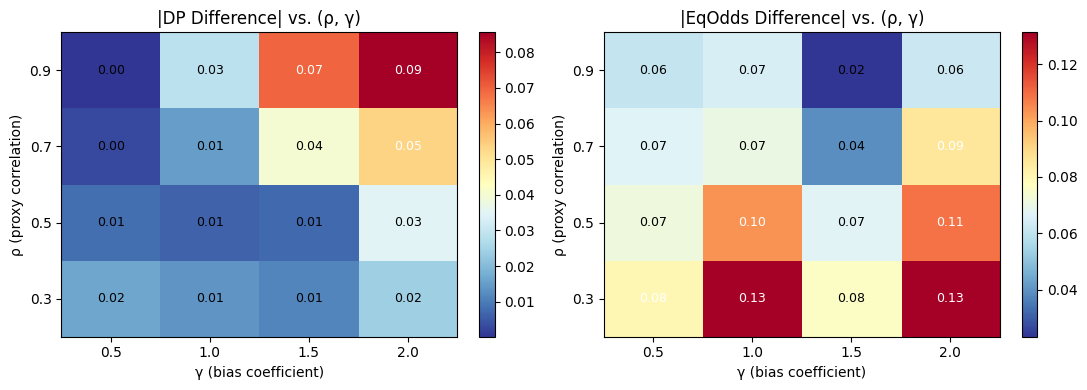

In [23]:
# ─────────────────────────────────────────────
# CELL 13b — Sensitivity Heatmap
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, grid, title in [
    (axes[0], dp_grid,  "|DP Difference| vs. (ρ, γ)"),
    (axes[1], eod_grid, "|EqOdds Difference| vs. (ρ, γ)"),
]:
    im = ax.imshow(grid, aspect="auto", cmap="RdYlBu_r", origin="lower")
    ax.set_xticks(range(len(gammas))); ax.set_xticklabels(gammas)
    ax.set_yticks(range(len(rhos)));   ax.set_yticklabels(rhos)
    ax.set_xlabel("γ (bias coefficient)"); ax.set_ylabel("ρ (proxy correlation)")
    ax.set_title(title)
    for i in range(len(rhos)):
        for j in range(len(gammas)):
            color = "white" if grid[i,j] > grid.max() * 0.6 else "black"
            ax.text(j, i, f"{grid[i,j]:.2f}", ha="center", va="center",
                    color=color, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig("figures/sensitivity_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
# ─────────────────────────────────────────────
# CELL 14 — Stratified Domain Analysis
# ─────────────────────────────────────────────
all_idx = np.arange(len(df))
tr_idx, te_idx = train_test_split(
    all_idx, test_size=0.3, random_state=RANDOM_STATE, stratify=Y
)
df_te = df.iloc[te_idx].reset_index(drop=True)
df_te["A"]         = A[te_idx]
df_te["y_true"]    = Y[te_idx]
df_te["y_pred_lr"] = baseline_results["Logistic Regression"]["pred"]
df_te["y_pred_rf"] = baseline_results["Random Forest"]["pred"]

cat_sizes = df["category"].value_counts()
def size_bin(cat):
    n = cat_sizes[cat]
    if n >= 80: return "high (≥80)"
    if n >= 40: return "medium (40-79)"
    return "low (<40)"
df_te["size_bin"] = df_te["category"].map(size_bin)

# Diagnostics: show what's in each bin
print("Test-set bin diagnostics:")
for bin_name in ["high (≥80)", "medium (40-79)", "low (<40)"]:
    sub = df_te[df_te["size_bin"] == bin_name]
    cats = df_te[df_te["size_bin"] == bin_name]["category"].unique().tolist()
    print(f"  {bin_name}: n={len(sub)}, A groups={sub['A'].nunique()}, "
          f"categories={cats}")
print()

stratified_rows = []
skipped = []
for model_name, pred_col in [("Logistic Regression", "y_pred_lr"),
                              ("Random Forest",       "y_pred_rf")]:
    for bin_name in ["high (≥80)", "medium (40-79)", "low (<40)"]:
        sub = df_te[df_te["size_bin"] == bin_name]
        if sub["A"].nunique() < 2:
            skipped.append(f"{model_name} | {bin_name}: only one A group (n={len(sub)})")
            continue
        if len(sub) < 10:
            skipped.append(f"{model_name} | {bin_name}: n={len(sub)} < 10, unreliable")
            continue
        dp  = abs(demographic_parity_difference(
            sub["y_true"], sub[pred_col], sensitive_features=sub["A"]))
        eod = abs(equalized_odds_difference(
            sub["y_true"], sub[pred_col], sensitive_features=sub["A"]))
        # flag bins with n < 50 — extreme metric values may be statistical artifacts
        reliable = "yes" if len(sub) >= 50 else "low-n"
        stratified_rows.append({
            "Model": model_name, "Size Bin": bin_name, "n": len(sub),
            "DP Diff": round(dp, 4), "EqOdds Diff": round(eod, 4),
            "Reliable": reliable,
        })

strat_df = pd.DataFrame(stratified_rows)
strat_df.to_csv("figures/stratified_domain.csv", index=False)
print(strat_df.to_string(index=False))
print("\nNote: 'low-n' bins (n < 50) have high-variance metrics — treat as indicative only.")
if skipped:
    print("\nSkipped bins (insufficient data for reliable fairness metrics):")
    for s in skipped:
        print(f"  {s}")

Test-set bin diagnostics:
  high (≥80): n=717, A groups=2, categories=['INFORMATION-TECHNOLOGY', 'BANKING', 'CHEF', 'ENGINEERING', 'AVIATION', 'FINANCE', 'DESIGNER', 'CONSTRUCTION', 'ARTS', 'HEALTHCARE', 'CONSULTANT', 'PUBLIC-RELATIONS', 'SALES', 'APPAREL', 'ADVOCATE', 'HR', 'FITNESS', 'DIGITAL-MEDIA', 'BUSINESS-DEVELOPMENT', 'ACCOUNTANT', 'TEACHER']
  medium (40-79): n=14, A groups=2, categories=['AGRICULTURE']
  low (<40): n=14, A groups=2, categories=['AUTOMOBILE', 'BPO']

              Model       Size Bin   n  DP Diff  EqOdds Diff Reliable
Logistic Regression     high (≥80) 717   0.0425       0.0866      yes
Logistic Regression medium (40-79)  14   0.5833       0.6667    low-n
Logistic Regression      low (<40)  14   0.2917       0.6667    low-n
      Random Forest     high (≥80) 717   0.0408       0.1640      yes
      Random Forest medium (40-79)  14   0.2500       0.7778    low-n
      Random Forest      low (<40)  14   0.3333       0.6667    low-n

Note: 'low-n' bins (n < 50) 

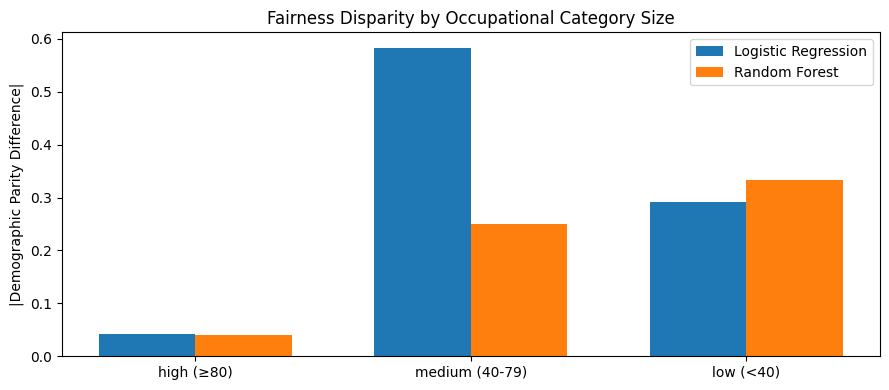

In [25]:
# ─────────────────────────────────────────────
# CELL 14b — Stratified Domain Bar Chart
# ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
bins_order  = ["high (≥80)", "medium (40-79)", "low (<40)"]
models_list = ["Logistic Regression", "Random Forest"]
x = np.arange(len(bins_order)); w = 0.35

for i, m in enumerate(models_list):
    vals = []
    for b in bins_order:
        row = strat_df[(strat_df["Model"]==m) & (strat_df["Size Bin"]==b)]["DP Diff"].values
        vals.append(row[0] if len(row) else 0)
    ax.bar(x + i*w, vals, w, label=m)

ax.set_xticks(x + w/2); ax.set_xticklabels(bins_order)
ax.set_ylabel("|Demographic Parity Difference|")
ax.set_title("Fairness Disparity by Occupational Category Size")
ax.legend()
plt.tight_layout()
plt.savefig("figures/stratified_domain.png", dpi=150, bbox_inches="tight")
plt.show()

In [26]:
# ─────────────────────────────────────────────
# CELL 15 — Intersectional Fairness (A × B)
# Addresses: intersectionality / "extend to intersectional fairness" suggestion
# ─────────────────────────────────────────────
def intersectional_table(y_true, y_pred, A, B, name=""):
    rows = []
    for a in [0, 1]:
        for b in [0, 1]:
            mask = (A == a) & (B == b)
            if mask.sum() == 0:
                continue
            tpr_group = y_pred[mask][y_true[mask]==1].mean() if (y_true[mask]==1).any() else np.nan
            rows.append({
                "Model": name, "A": a, "B": b, "n": int(mask.sum()),
                "Sel Rate": round(y_pred[mask].mean(), 4),
                "TPR":      round(tpr_group, 4),
            })
    return pd.DataFrame(rows)

eg_pred = mitigation_results["ExpGrad DP (In)"].get("pred", None)
if eg_pred is None:
    eg_pred = eg.predict(X_te)

inter_dfs = []
for name, pred in [
    ("Baseline LR",       baseline_results["Logistic Regression"]["pred"]),
    ("LR + ExpGrad (A)",  eg_pred),
]:
    inter_dfs.append(intersectional_table(np.array(y_te), np.array(pred),
                                          A_te, B_te, name=name))

inter_df = pd.concat(inter_dfs, ignore_index=True)
inter_df.to_csv("figures/intersectional.csv", index=False)
print(inter_df.to_string(index=False))

# DP gap on B within each A stratum — tests whether mitigating A leaves B-disparity intact
print("\nDP gap on B-attribute within each A stratum:")
for name, pred in [("Baseline LR",      baseline_results["Logistic Regression"]["pred"]),
                   ("LR + ExpGrad (A)", eg_pred)]:
    for a_val in [0, 1]:
        mask = (A_te == a_val)
        if mask.sum() > 20:
            dp_B = abs(demographic_parity_difference(
                y_te[mask], np.array(pred)[mask], sensitive_features=B_te[mask]))
            print(f"  {name} | A={a_val}: DP on B = {dp_B:.4f}")

           Model  A  B   n  Sel Rate    TPR
     Baseline LR  0  0 253    0.6245 0.8443
     Baseline LR  0  1 122    0.6639 0.8657
     Baseline LR  1  0 127    0.6378 0.7765
     Baseline LR  1  1 243    0.6914 0.7989
LR + ExpGrad (A)  0  0 253    0.5929 0.8033
LR + ExpGrad (A)  0  1 122    0.5820 0.8060
LR + ExpGrad (A)  1  0 127    0.5512 0.6824
LR + ExpGrad (A)  1  1 243    0.6132 0.7143

DP gap on B-attribute within each A stratum:
  Baseline LR | A=0: DP on B = 0.0394
  Baseline LR | A=1: DP on B = 0.0536
  LR + ExpGrad (A) | A=0: DP on B = 0.0109
  LR + ExpGrad (A) | A=1: DP on B = 0.0620


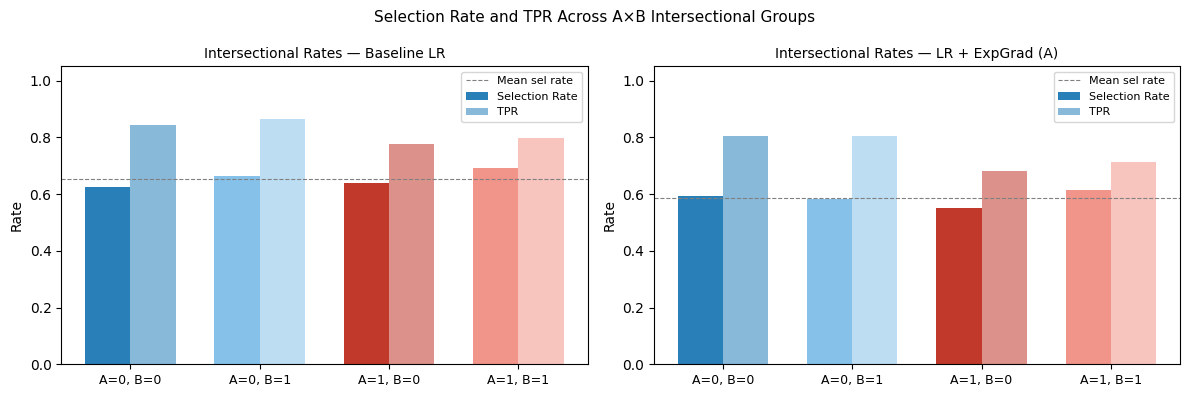

In [27]:
# ─────────────────────────────────────────────
# CELL 15b — Intersectional Bar Chart (Selection Rate + TPR by A×B group)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
group_labels = ["A=0, B=0", "A=0, B=1", "A=1, B=0", "A=1, B=1"]
colors_ab    = ["#2980b9", "#85c1e9", "#c0392b", "#f1948a"]

for ax, model_name in zip(axes, ["Baseline LR", "LR + ExpGrad (A)"]):
    sub = inter_df[inter_df["Model"] == model_name]
    sel_rates, tpr_vals = [], []
    for a in [0, 1]:
        for b in [0, 1]:
            row = sub[(sub["A"] == a) & (sub["B"] == b)]
            sel_rates.append(float(row["Sel Rate"].values[0]) if len(row) else 0)
            tpr_vals.append(float(row["TPR"].values[0]) if len(row) else 0)
    x = np.arange(len(group_labels)); w = 0.35
    ax.bar(x - w/2, sel_rates, w, label="Selection Rate", color=colors_ab)
    ax.bar(x + w/2, tpr_vals,  w, label="TPR",            color=colors_ab, alpha=0.55)
    ax.set_xticks(x); ax.set_xticklabels(group_labels, fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel("Rate")
    ax.set_title(f"Intersectional Rates — {model_name}", fontsize=10)
    ax.axhline(np.mean(sel_rates), color="gray", linestyle="--", linewidth=0.8, label="Mean sel rate")
    ax.legend(fontsize=8)

plt.suptitle("Selection Rate and TPR Across A×B Intersectional Groups", fontsize=11)
plt.tight_layout()
plt.savefig("figures/intersectional_bar.png", dpi=150, bbox_inches="tight")
plt.show()

Top 15 features by |SHAP(A=1) − SHAP(A=0)|:
Feature                     SHAP A=0   SHAP A=1       Diff
learned                      0.01746    0.11294   +0.09548
paint                        0.09291    0.01002   -0.08289
comments                     0.09188    0.01731   -0.07457
aix                          0.00000    0.07384   +0.07384
strategic marketing          0.07750    0.01130   -0.06620
deploy                       0.07567    0.01035   -0.06532
estimates                    0.10098    0.03743   -0.06354
counters                     0.06797    0.00489   -0.06308
placed                       0.01001    0.07283   +0.06282
familiarity                  0.01583    0.07724   +0.06141
outlets                      0.09128    0.03046   -0.06083
prices                       0.07532    0.01633   -0.05899
time budget                  0.08842    0.03139   -0.05702
complaints                   0.08492    0.02957   -0.05535
visit                        0.00536    0.06060   +0.05525


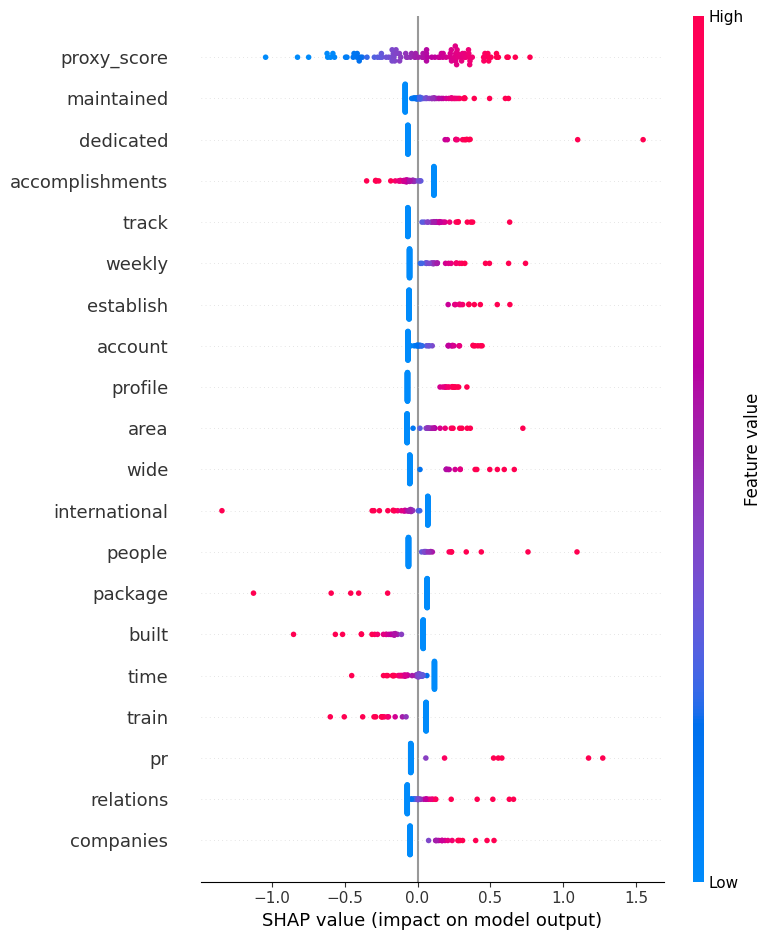

In [28]:
# ─────────────────────────────────────────────
# CELL 16 — SHAP Mechanistic Analysis
# Addresses: "provide mechanistic explanation of proxy encoding" suggestion
# ─────────────────────────────────────────────
import shap

lr_model   = baseline_results["Logistic Regression"]["model"]
feat_names = vectorizer.get_feature_names_out().tolist() + ["proxy_score"]

bg_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_tr), 200, replace=False)
explainer = shap.LinearExplainer(lr_model, X_tr[bg_idx])

explain_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_te), 100, replace=False)
shap_values = explainer.shap_values(X_te[explain_idx])

# Per-group mean |SHAP| and the difference between groups
A_sub         = A_te[explain_idx]
mean_abs_A0   = np.abs(shap_values[A_sub == 0]).mean(axis=0)
mean_abs_A1   = np.abs(shap_values[A_sub == 1]).mean(axis=0)
shap_diff     = mean_abs_A1 - mean_abs_A0
top_diff_idx  = np.argsort(np.abs(shap_diff))[-15:][::-1]

print("Top 15 features by |SHAP(A=1) − SHAP(A=0)|:")
print(f"{'Feature':<25} {'SHAP A=0':>10} {'SHAP A=1':>10} {'Diff':>10}")
for idx in top_diff_idx:
    print(f"{feat_names[idx]:<25} {mean_abs_A0[idx]:>10.5f} "
          f"{mean_abs_A1[idx]:>10.5f} {shap_diff[idx]:>+10.5f}")

shap.summary_plot(shap_values, X_te[explain_idx],
                  feature_names=feat_names, max_display=20, show=False)
plt.tight_layout()
plt.savefig("figures/shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

In [29]:
# ─────────────────────────────────────────────
# CELL 17 — Qualitative Resume Excerpts (Appendix)
# Addresses: "lack of deeper interpretation / qualitative examples" weakness
# ─────────────────────────────────────────────
svd_q = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)
Xq_all = svd_q.fit_transform(X[:, :-1])[:, :5].mean(axis=1)
Xq_all = (Xq_all - Xq_all.mean()) / (Xq_all.std() + 1e-8)

lr_prob_all = baseline_results["Logistic Regression"]["model"].predict_proba(X_scaled)[:, 1]
lr_pred_all = baseline_results["Logistic Regression"]["model"].predict(X_scaled)

df_contrast = pd.DataFrame({
    "category": df["category"].values,
    "q_score":  Xq_all,
    "A":        A,
    "y_pred":   lr_pred_all,
    "y_prob":   lr_prob_all,
    "text":     df["text"].values,
})

df_pos = df_contrast[(df_contrast["y_pred"] == 1) & (df_contrast["A"] == 1)].reset_index(drop=True)
df_neg = df_contrast[(df_contrast["y_pred"] == 0) & (df_contrast["A"] == 0)].reset_index(drop=True)

print("CONTRAST PAIRS (selected A=1 vs. rejected A=0):\n")
for k in range(min(3, len(df_pos), len(df_neg))):
    p, n = df_pos.iloc[k], df_neg.iloc[k]
    print(f"--- Pair {k+1} ---")
    print(f"Selected (A=1): category={p['category']}, q={p['q_score']:.2f}, p(select)={p['y_prob']:.3f}")
    print(f"  {p['text'][:200]}...\n")
    print(f"Rejected (A=0): category={n['category']}, q={n['q_score']:.2f}, p(select)={n['y_prob']:.3f}")
    print(f"  {n['text'][:200]}...\n")

df_contrast.head(20).to_csv("figures/qualitative_excerpts.csv", index=False)

CONTRAST PAIRS (selected A=1 vs. rejected A=0):

--- Pair 1 ---
Selected (A=1): category=ACCOUNTANT, q=1.86, p(select)=1.000
  accountant
summary
accounting professional with twenty years of experience in inventory and manufacturing accounting  ability to fill in at a moment s notice  quickly
mastering new systems  processes ...

Rejected (A=0): category=ACCOUNTANT, q=-0.56, p(select)=0.002
  project accountant
career focus
dedicated and focused professional who excels at prioritizing  completing multiple tasks simultaneously and following through to achieve project
goals  seeking a role o...

--- Pair 2 ---
Selected (A=1): category=ACCOUNTANT, q=1.17, p(select)=1.000
  senior accountant
experience
company name june      to current senior accountant
city   state
prepare quarterly and annual financial statements for    multi family communities for distribution to inve...

Rejected (A=0): category=ACCOUNTANT, q=1.52, p(select)=0.004
  accountant
summary
self motivated accountant offering